<a href="https://colab.research.google.com/github/batireeduienkh6-source/2026_tues_bigdatacomputing_class/blob/main/%EA%B8%B0%EB%A7%90_%EA%B3%BC%EC%A0%9C_20250068.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

In [5]:
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url)
df = df.dropna()
print(df.shape)
df.head()

(1649, 22)


,Country,Year,Status,Life expectancy,Adult mortality,Infant deaths,Alcohol,Percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 years,Thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [9]:
features = [
    "Adult mortality",
    "BMI",
    "GDP",
    "Alcohol"
]

target = "Life expectancy"

X = df[features]
y = df[target]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1319, 4)
(330, 4)


In [11]:
X_train_small = X_train.sample(
    n=50,
    random_state=42
)

y_train_small = y_train.loc[X_train_small.index]

print(X_train_small.shape)
print(y_train_small.shape)

(50, 4)
(50,)


In [12]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

linear_model.fit(
    X_train_small,
    y_train_small
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [13]:
poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("regressor", LinearRegression())
])

poly_model.fit(
    X_train_small,
    y_train_small
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=3)),
                ('regressor', LinearRegression())])

In [14]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(
    X_train_small,
    y_train_small
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=3)), ('ridge', Ridge())])

In [15]:
joblib.dump(
    linear_model,
    "linear.pkl"
)

joblib.dump(
    poly_model,
    "poly.pkl"
)

joblib.dump(
    ridge_model,
    "ridge.pkl"
)

print("모델 저장 완료")

모델 저장 완료


In [16]:
def evaluate_model(model, model_name):

    train_pred = model.predict(X_train_small)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(
        y_train_small,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    train_mse = mean_squared_error(
        y_train_small,
        train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        test_pred
    )

    if "poly" in model.named_steps:
        complexity = model.named_steps[
            "poly"
        ].fit_transform(
            X_train_small
        ).shape[1]
    else:
        complexity = X_train_small.shape[1]

    return [
        model_name,
        train_r2,
        test_r2,
        train_mse,
        test_mse,
        complexity
    ]

In [17]:
results = []

results.append(
    evaluate_model(
        linear_model,
        "Linear"
    )
)

results.append(
    evaluate_model(
        poly_model,
        "Poly"
    )
)

results.append(
    evaluate_model(
        ridge_model,
        "Ridge"
    )
)

In [18]:
performance_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train_R2",
        "Test_R2",
        "Train_MSE",
        "Test_MSE",
        "Complexity"
    ]
)

performance_df

,Model,Train_R2,Test_R2,Train_MSE,Test_MSE,Complexity
0,Linear,0.733584,0.579432,29.216463,29.869771,4
1,Poly,0.961695,-476.580782,4.200751,33918.973712,35
2,Ridge,0.923786,0.123047,8.357963,62.283377,35


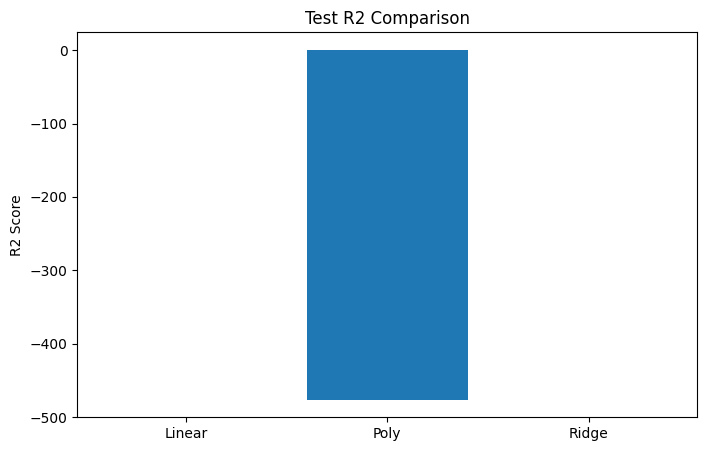

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    performance_df["Model"],
    performance_df["Test_R2"]
)

plt.title("Test R2 Comparison")
plt.ylabel("R2 Score")

plt.show()

In [20]:
import os

print(os.listdir())

['.config', 'ridge.pkl', 'linear.pkl', 'poly.pkl', 'sample_data']


In [42]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Life Expectancy Prediction",
    layout="wide"
)

st.title("Life Expectancy Prediction Dashboard")

linear_model = joblib.load("linear.pkl")
poly_model = joblib.load("poly.pkl")
ridge_model = joblib.load("ridge.pkl")

st.sidebar.header("Input Features")

adult_mortality = st.sidebar.slider(
    "Adult Mortality",
    1,
    800,
    200
)

bmi = st.sidebar.slider(
    "BMI",
    1.0,
    90.0,
    25.0
)

gdp = st.sidebar.slider(
    "GDP",
    0.0,
    120000.0,
    10000.0
)

alcohol = st.sidebar.slider(
    "Alcohol",
    0.0,
    20.0,
    5.0
)

input_df = pd.DataFrame({
    "Adult mortality":[adult_mortality],
    "BMI":[bmi],
    "GDP":[gdp],
    "Alcohol":[alcohol]
})


model_name = st.selectbox(
    "Choose Model",
    ["Linear","Poly","Ridge"]
)

if model_name == "Linear":
    model = linear_model
elif model_name == "Poly":
    model = poly_model
else:
    model = ridge_model

prediction = model.predict(input_df)[0]

st.markdown("## Predicted Life Expectancy")
st.success(f"{prediction:.2f} years")

st.header("Model Performance Comparison")

performance_df = pd.read_csv("performance.csv")

st.dataframe(
    performance_df,
    use_container_width=True
)

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(
    performance_df["Model"],
    performance_df["Test_R2"]
)

ax.set_title("Test R² Comparison")
ax.set_ylabel("R² Score")

st.pyplot(fig)

Overwriting app.py


In [23]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 98.2 MB/s eta 0:00:00


In [32]:
print(list(X.columns))

['Adult mortality', 'BMI', 'GDP', 'Alcohol']


In [35]:
!pkill -f streamlit

In [36]:
!nohup streamlit run app.py &

nohup: appending output to 'nohup.out'


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3EZJ9hcZkiUmoADZlpLRKXfHx2o_cCEUUsHWFQERPZYbLaTH")

In [41]:
!nohup streamlit run app.py &

nohup: appending output to 'nohup.out'


In [40]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://skillful-antennae-glory.ngrok-free.dev" -> "http://localhost:8501"


In [43]:
performance_df.to_csv(
    "performance.csv",
    index=False
)

In [44]:
import os
print(os.listdir())

['.config', 'performance.csv', 'nohup.out', 'ridge.pkl', 'linear.pkl', 'poly.pkl', 'app.py', 'sample_data']


In [45]:
performance_df.to_csv(
    "performance.csv",
    index=False
)

print("performance.csv saved")

performance.csv saved


In [46]:
!pkill -f streamlit

In [47]:
!nohup streamlit run app.py &

nohup: appending output to 'nohup.out'


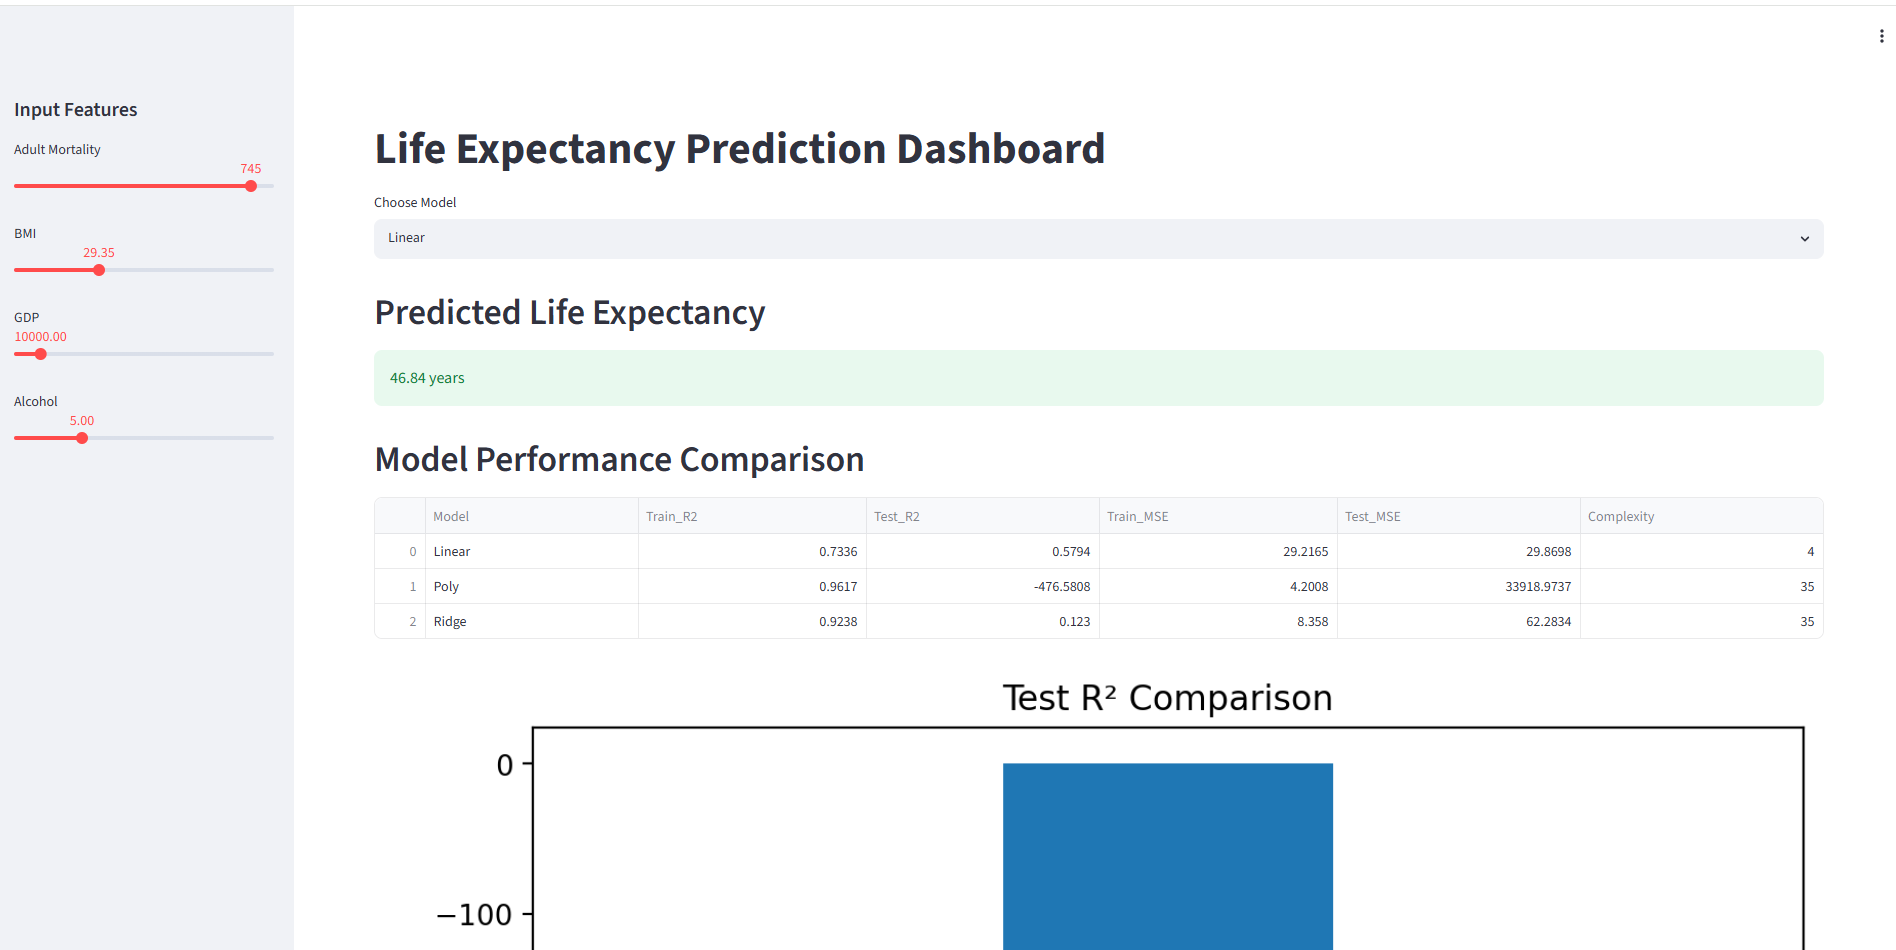

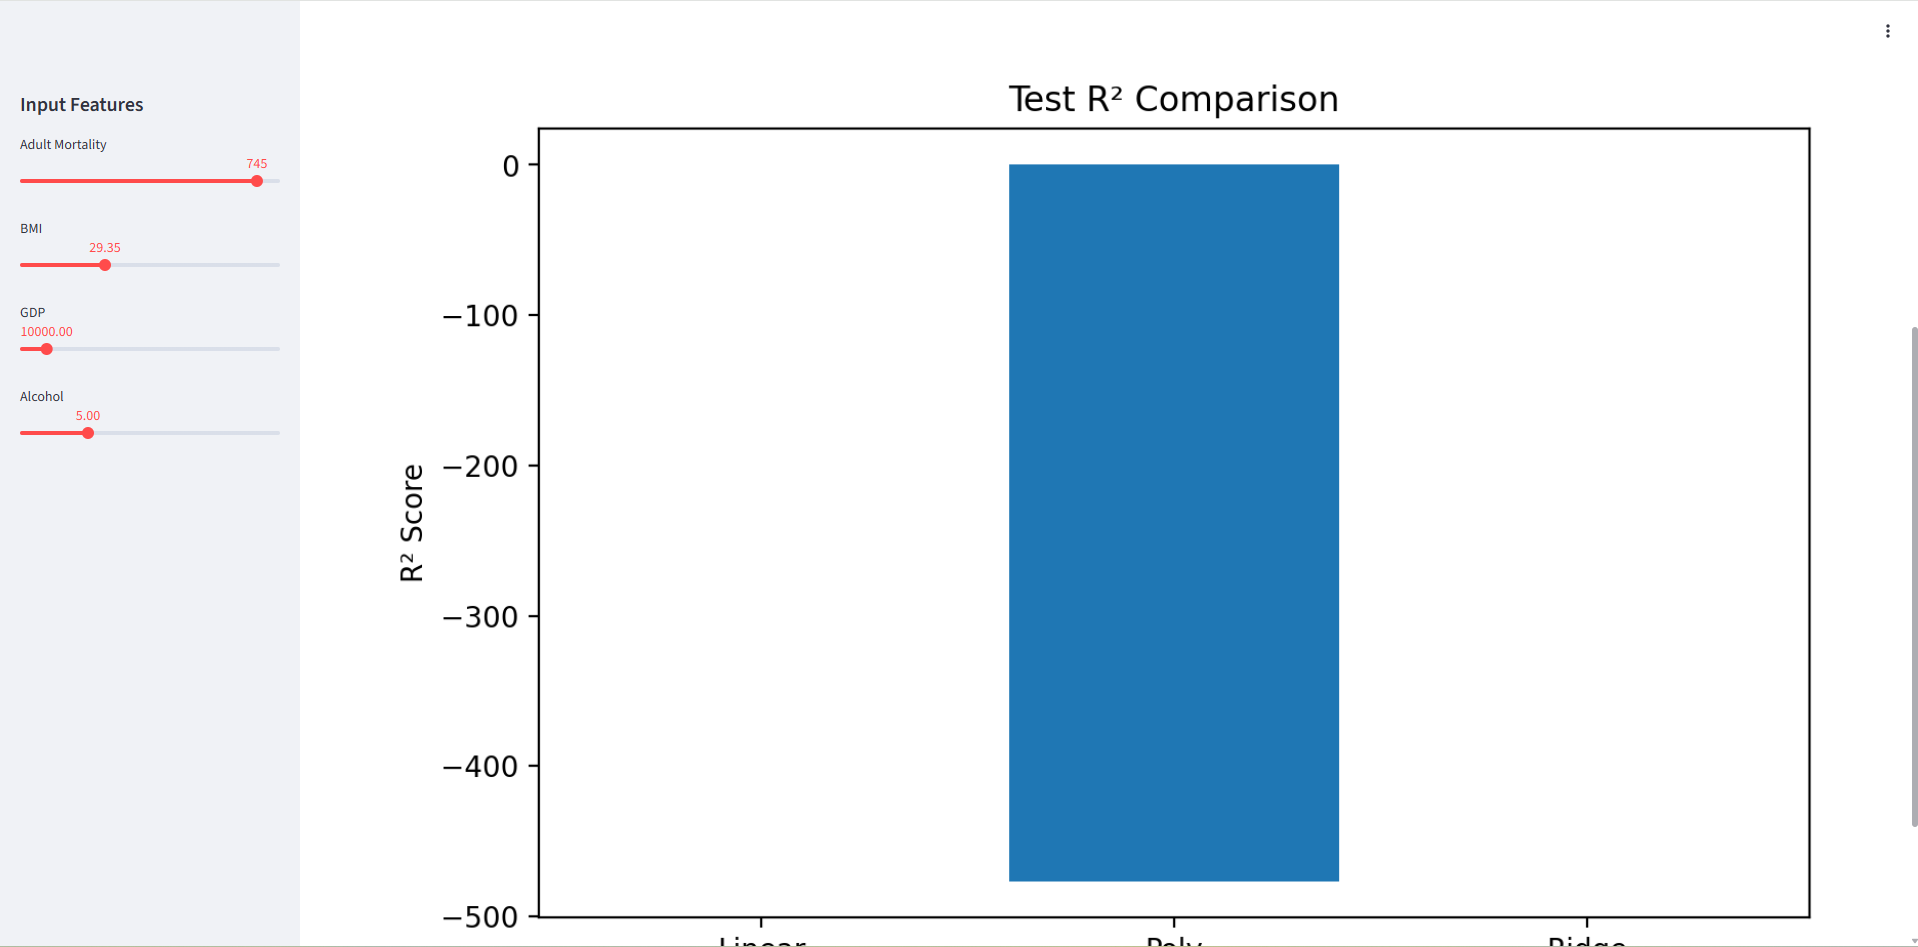